In [1]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

# FP/FN

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# --- 脚本配置 ---
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# 定义通用的 Accesses 提取模式
ACCESS_PATTERNS = {
    "index_accesses":    r"Index accesses:\s*([0-9]+)",
    "candidate_accesses":r"Candidate accesses:\s*([0-9]+)",
}

def run_experiment(cmd, sweep_param_name, sweep_value, existing_patterns):
    """
    通用函数：运行程序，提取所有指标（包括 Accesses）。
    """
    print(f"Running with {sweep_param_name} = {sweep_value}...")
    
    # 组合所有需要提取的模式
    all_patterns = {**existing_patterns, **ACCESS_PATTERNS}
    metrics = {}

    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, check=True)
    except subprocess.CalledProcessError as e:
        print(f"Error running {cmd}: Return code {e.returncode}. Stderr: {e.stderr}")
        return None
    except FileNotFoundError:
        print(f"Error: Executable not found at {EXECUTABLE}. Please check the path.")
        sys.exit(1)

    output = proc.stdout
    
    for key, pat in all_patterns.items():
        m = re.search(pat, output)
        if m:
            if 'accesses' in key:
                # Accesses 数量为整数
                metrics[key] = int(m.group(1))
            else:
                metrics[key] = float(m.group(1))
        else:
            # 找不到指标时，设为 None (对 PR) 或 0 (对 Accesses)
            if 'accesses' in key:
                #  print(f"⚠️ Access metric '{key}' not found for {sweep_param_name}={sweep_value}")
                 metrics[key] = 0
            else:
                #  print(f"⚠️ {key} not found for {sweep_param_name}={sweep_value}")
                 metrics[key] = None

    metrics[sweep_param_name] = sweep_value 
    return metrics

def plot_accesses_stacked_bar(df, sweep_param_name, title_suffix, fig_path):
    """
    通用函数：绘制 Index/Candidate Accesses 堆叠柱状图。
    """
    if 'index_accesses' in df.columns and 'candidate_accesses' in df.columns:
        plt.figure(figsize=(10, 6))

        # 绘制 Index Accesses 柱状图 (底部)
        plt.bar(
            df[sweep_param_name],
            df["index_accesses"],
            width=df[sweep_param_name].diff().min() * 0.8 if len(df) > 1 else 1.5, # 动态调整柱子宽度
            label='Index Accesses',
            color='tab:blue'
        )

        # 绘制 Candidate Accesses 柱状图 (堆叠在 Index Accesses 之上)
        plt.bar(
            df[sweep_param_name],
            df["candidate_accesses"],
            width=df[sweep_param_name].diff().min() * 0.8 if len(df) > 1 else 1.5,
            bottom=df["index_accesses"], # 关键：使用 index_accesses 作为底部
            label='Candidate Accesses',
            color='tab:orange'
        )

        plt.xlabel(f"{sweep_param_name.replace('_', ' ').title()}")
        plt.ylabel("Total Accesses Count (Index + Candidate)")
        plt.title(f"Index and Candidate Accesses Sweep on {sweep_param_name.replace('_', ' ').title()} ({title_suffix})")
        plt.legend()
        plt.grid(axis='y', linestyle=':', alpha=0.7)

        # 设置 X 轴刻度，确保每个值都显示
        plt.xticks(df[sweep_param_name])
        plt.show()
        plt.savefig(fig_path)
        print(f"Accesses 堆叠柱状图已保存至: {fig_path}")
        # plt.show()
    else:
        print(f"\n⚠️ 缺失 Accesses 数据，无法生成 {title_suffix} 的堆叠柱状图。请检查程序输出。")
    plt.close() # 关闭图形，释放内存

In [ ]:
def run_method_sweep(method_name, maxDist_values, fixed_seed_len="16"):
    """
    运行特定方法 (method_name) 对 maxDist 的参数扫描实验。
    """
    print(f"\n# ==========================================================================")
    print(f"=== PART: Sweep maxDist (Method: {method_name.upper()}) ===")
    print(f"=========================================================================#")
    
    results = []
    sweep_param = "maxDist"

    # 提取 Precision/Recall 指标 (假设所有方法的输出格式相同)
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
        "index_access": r"Index Accesses:\s*([0-9.eE+-]+)",
        "candidate_access": r"Candidate Accesses:\s*([0-9.eE+-]+)",
    }
    
    for maxDist in maxDist_values:
        print(f"-> Running {method_name.upper()} with maxDist={maxDist}...")
        
        # 构建命令行参数
        cmd = [
            EXECUTABLE,
            "--truncate_ref_len", "400000",
            "--anchor_len", "150", 
            "--seed_len", fixed_seed_len, # 固定 seed_len
            "--num_queries", "1000",
            "--maxDist", str(maxDist), 
            "--auto_gen", "false",
            "--method", method_name # 传入当前方法名
        ]
        
        # run_experiment 假设能够执行 cmd 并根据 patterns 提取指标
        metrics = run_experiment(cmd, sweep_param, maxDist, patterns)
        if metrics is None:
            # 如果 run_experiment 返回 None (通常是程序执行失败)
            # 创建一个只包含基本信息的字典，其他指标设为 NaN
            metrics = {
                sweep_param: maxDist,
                'method': method_name,
                # 其他指标设为 None，pandas 会将其处理为 NaN
                "avg_precision": None,
                "avg_recall": None,
                "index_accesses": None,
                "candidate_accesses": None
                # ... (需要将所有期望的指标都列出并设为 None)
            }
            print(f"⚠️ 警告: {method_name.upper()} maxDist={maxDist} 实验失败或无输出，记录为缺失数据。")
        else:
            # 如果 run_experiment 成功返回指标字典
            # 确保 method_name 存在（虽然你的原代码已经做了）
            metrics['method'] = method_name
            
        results.append(metrics)
            
    # --- 数据处理与可视化 ---
    df = pd.DataFrame(results)
    
    if df.empty:
        print(f"{method_name.upper()} 实验结果为空，跳过保存和绘图。")
        return

    print(f"\n--- {method_name.upper()} 结果 DataFrame ---")
    print(df)

    # 定义输出路径
    csv_path = f"./csv/sweep_results_maxDist_{method_name}.csv"
    fig_pr_path = f"./fig/sweep_precision_recall_maxDist_{method_name}.png"
    fig_access_path = f"./fig/sweep_accesses_maxDist_{method_name}.png" 

    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    os.makedirs(os.path.dirname(fig_pr_path), exist_ok=True)

    # 1. 保存结果
    df.to_csv(csv_path, index=False)
    print(f"\n{method_name.upper()} 结果已保存至: {csv_path}")

    # 2. 绘图 1: Precision 和 Recall
    plt.figure(figsize=(10, 6))
    plt.plot(df[sweep_param], df["avg_precision"], marker="o", label='Precision')
    plt.plot(df[sweep_param], df["avg_recall"], marker="s", label='Recall') 
    plt.xlabel("Max Distance (Error Tolerance)") 
    plt.ylabel("Average Metric Value")
    plt.title(f"Effect of Max Distance on Precision and Recall (Method: {method_name.upper()})") 
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig(fig_pr_path)
    print(f"{method_name.upper()} Precision/Recall 图已保存至: {fig_pr_path}")
    plt.close()

    # 3. 绘图 2: Index/Candidate Accesses 堆叠柱状图 (需要 plot_accesses_stacked_bar 函数)
    # 假设你已经定义了 plot_accesses_stacked_bar 函数
    plot_accesses_stacked_bar(df, sweep_param, f"Method: {method_name.upper()}", fig_access_path)
    
    # 为了防止没有定义该函数而报错，可以注释掉或提供一个占位符
    print(f"{method_name.upper()} Accesses 图（需要 plot_accesses_stacked_bar）路径: {fig_access_path}")

    return df # 返回 DataFrame 供总对比使用

## seed-and-extend: maxDist -> seedlength

In [4]:
def plot_comparison_figures(all_df, sweep_param_name):
    """
    绘制对比 Precision/Recall 和 Index/Candidate 堆叠 Accesses 的总图。
    """
    print("\n# ==========================================================================")
    print("=== FINAL PART: Plotting Comparison Figures ===")
    print("=========================================================================#")

    if all_df.empty:
        print("所有实验结果为空，无法生成总对比图。")
        return

    # --- 图 1: Precision 和 Recall 对比图 (保持不变) ---
    plt.figure(figsize=(12, 8))
    
    # 获取唯一的 maxDist 值用于设置 x 轴刻度
    x_ticks = all_df[sweep_param_name].unique()
    methods = all_df['method'].unique()
    num_methods = len(methods)
    
    styles = {
        'sae':    {'marker': 'o', 'color': 'tab:blue'},
        'anchor': {'marker': 's', 'color': 'tab:green'},
        'mtree':  {'marker': '^', 'color': 'tab:red'}
    }

    # 1. 绘制 Precision
    ax1 = plt.gca()
    for method in methods:
        df_method = all_df[all_df['method'] == method]
        style = styles.get(method, {})
        ax1.plot(df_method[sweep_param_name], df_method["avg_precision"], 
                 label=f'{method.upper()} Precision', 
                 linestyle='-', **style)

    # 2. 绘制 Recall
    for method in methods:
        df_method = all_df[all_df['method'] == method]
        style = styles.get(method, {})
        ax1.plot(df_method[sweep_param_name], df_method["avg_recall"], 
                 label=f'{method.upper()} Recall', 
                 linestyle='--', **style)

    ax1.set_xlabel("Max Distance (Error Tolerance)")
    ax1.set_ylabel("Average Metric Value (Precision/Recall)")
    ax1.set_title("Comparison of Precision and Recall Across Methods")
    ax1.legend(loc='lower right')
    ax1.grid(True)
    ax1.set_xticks(x_ticks) # 设置 X 轴刻度
    
    fig_pr_comp_path = "./fig/comparison_precision_recall_maxDist.png"
    plt.show()
    plt.savefig(fig_pr_comp_path)
    print(f"总 Precision/Recall 对比图已保存至: {fig_pr_comp_path}")
    plt.close()

    # --- 图 2: Index/Candidate 堆叠 Accesses 分组柱状图 (修改部分) ---
    if 'index_accesses' in all_df.columns and 'candidate_accesses' in all_df.columns:
        plt.figure(figsize=(12, 6))
        ax2 = plt.gca()
        
        max_dists = all_df[sweep_param_name].unique()
        
        # 动态计算柱子宽度
        bar_width = 0.8 / num_methods # 0.8 是组内总宽度
        
        # 定义颜色的映射
        method_colors = {
            'sae': 'tab:blue',
            'anchor': 'tab:green',
            'mtree': 'tab:red'
        }
        
        # 遍历每个 maxDist 作为一组
        for i, max_d in enumerate(max_dists):
            df_group = all_df[all_df[sweep_param_name] == max_d].copy()
            
            # 确保方法按固定顺序排列，以便柱子顺序一致
            df_group['method'] = pd.Categorical(df_group['method'], categories=methods, ordered=True)
            df_group = df_group.sort_values('method')
            
            # 计算组内起始位置 (用于左移/右移)
            center_x = i
            group_start_x = center_x - (bar_width * num_methods / 2) + (bar_width / 2)
            
            # 遍历组内的每个方法绘制堆叠柱子
            for j, method in enumerate(df_group['method']):
                data = df_group[df_group['method'] == method].iloc[0]
                
                index_count = data['index_accesses']
                candidate_count = data['candidate_accesses']
                
                bar_pos = group_start_x + j * bar_width
                
                # 绘制 Index Accesses (底部)
                ax2.bar(bar_pos, index_count, bar_width, 
                        color=method_colors[method], alpha=0.9, 
                        label=f'{method.upper()} Index' if i == 0 else "", # 只在第一个 maxDist 组添加标签
                        edgecolor='black')
                
                # 绘制 Candidate Accesses (堆叠在 Index 之上)
                ax2.bar(bar_pos, candidate_count, bar_width, 
                        bottom=index_count, 
                        color=method_colors[method], alpha=0.5, 
                        label=f'{method.upper()} Candidate' if i == 0 else "", 
                        edgecolor='black')

        # 设置 X 轴刻度：显示 maxDist 值，并将其放置在分组的中心
        ax2.set_xticks(range(len(max_dists)))
        ax2.set_xticklabels(max_dists)
        
        # 设置 Y 轴为对数刻度 (Log Scale)
        ax2.set_yscale('log')
        
        ax2.set_xlabel("Max Distance (Error Tolerance)")
        ax2.set_ylabel("Accesses Count (Index + Candidate, Log Scale)")
        ax2.set_title("Comparison of Index/Candidate Stacked Accesses Across Methods (Log Scale)")
        
        # 创建自定义图例：使用两个循环，一个用于 Index（深色），一个用于 Candidate（浅色）
        legend_handles = []
        for method in methods:
            color = method_colors[method]
            # Index (深色)
            legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.9, label=f'{method.upper()} Index'))
            # Candidate (浅色)
            legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.5, label=f'{method.upper()} Candidate'))

        ax2.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1))
        ax2.grid(axis='y', linestyle=':', alpha=0.7)
        
        plt.tight_layout(rect=[0, 0, 0.95, 1]) # 调整布局以适应图例
        
        fig_access_comp_path = "./fig/comparison_accesses_grouped_stacked_log_maxDist.png"
        plt.show()
        plt.savefig(fig_access_comp_path)
        print(f"总 Accesses 堆叠分组柱状图（Log Y）已保存至: {fig_access_comp_path}")
        plt.close()
    else:
        print("⚠️ 无法计算 Accesses，跳过 Accesses 对比图。")
        
    return

In [ ]:
# 1. 定义遍历参数
MAX_DIST_VALUES = range(1, 12, 2) # maxDist 从 1 到 12

# 2. 定义要测试的方法
METHODS_TO_TEST = ["sae", "mtree"]

# 3. 循环运行所有方法
all_results_df = []
for method in METHODS_TO_TEST:
    df_result = run_method_sweep(method, MAX_DIST_VALUES)
    if df_result is not None and not df_result.empty:
        all_results_df.append(df_result)


# ==========================================================================
=== PART: Sweep maxDist (Method: SAE) ===
=========================================================================#
-> Running SAE with maxDist=1...
Running with maxDist = 1...
-> Running SAE with maxDist=3...
Running with maxDist = 3...


KeyboardInterrupt: 


# ==========================================================================
=== FINAL PART: Plotting Comparison Figures ===
=========================================================================#


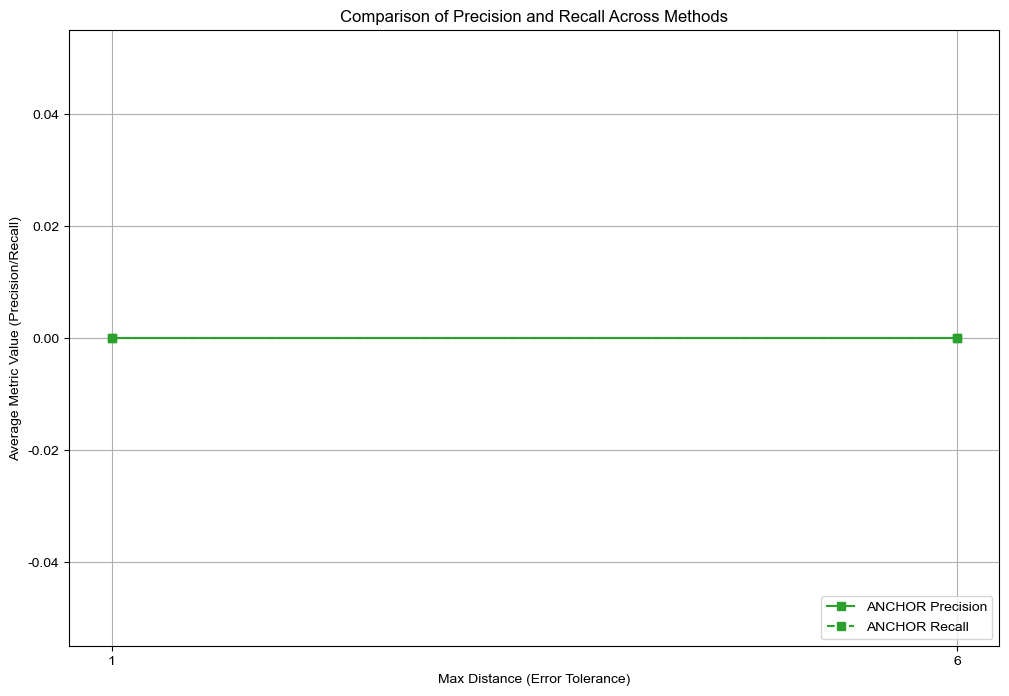

总 Precision/Recall 对比图已保存至: ./fig/comparison_precision_recall_maxDist.png


/tmp/ipykernel_559341/2409497848.py:113: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


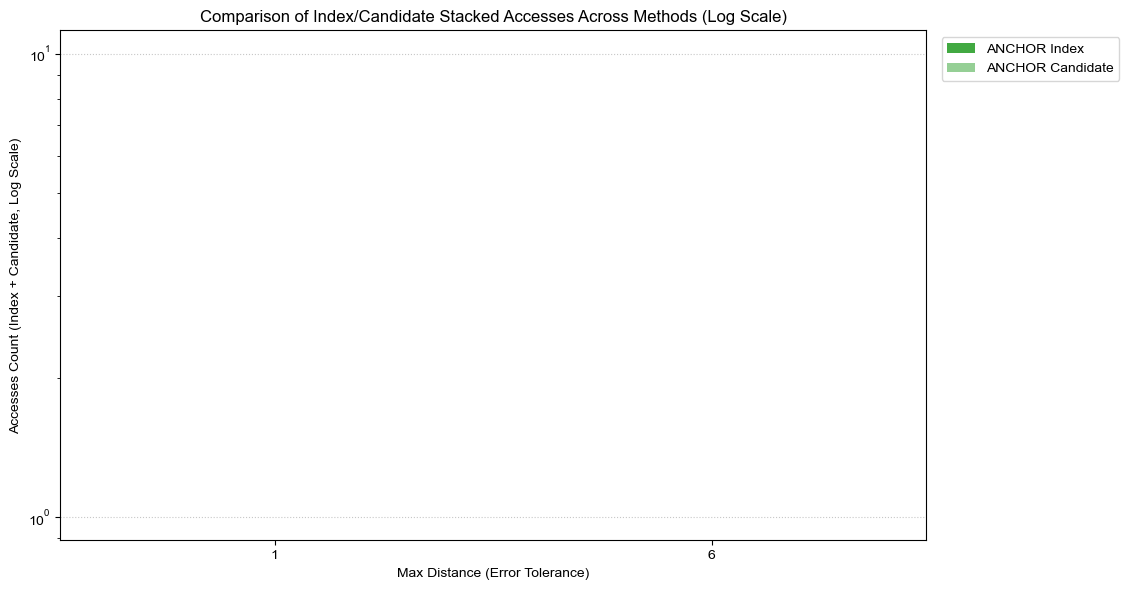

总 Accesses 堆叠分组柱状图（Log Y）已保存至: ./fig/comparison_accesses_grouped_stacked_log_maxDist.png


In [ ]:
if all_results_df:
    final_comparison_df = pd.concat(all_results_df, ignore_index=True)
    plot_comparison_figures(final_comparison_df, "maxDist")
else:
    print("\n所有实验均未返回有效数据，无法生成总对比图。")

In [ ]:
final_comparison_df.to_csv("./csv/comparison_updatedTP.csv")